# 06 · Build an organizer from data you already have

The other notebooks open a project that was *laid out* for the purpose:
authored dicts in `MetaData/`, data underneath in `<Modality>Data/<SampleID>/`.
That is the tidy case, and it is not the common one.

The common one is this: nine samples, fifteen techniques, and the data already
exists — the micrographs on the microscope's share, the scattering on a
beamline mount, the spectra in whatever folder somebody made that afternoon.
None of it is going to move, and copying it would only create a second copy to
keep in sync.

So the organizer **links** instead of collecting. It is one object, keyed on
`sample_id`, that knows where everything is:

```
Organizer
 └── sample_id              "CuAu05"
      ├── modality          uvvis · waxs1d · tem · tomo · …
      │    └── frames       t = 0 s, 45 s, 90 s … / T = 30 °C, 35 °C …
      ├── params            what it was made from — filterable
      └── derived           what the analyses found — filterable too
```

and then `wb.plot("CuAu05", "uvvis")` draws it, whatever "it" turns out to be.

## Some data, somewhere

Generated once so this notebook runs on a bare checkout. For the rest of the
notebook, pretend `DATA` is three different mounts you do not control.

In [1]:
from pathlib import Path

from NanoOrganizer import new_organizer, open_project
from NanoOrganizer.demo import build_showcase_project, showcase_truth

DATA = Path.home() / "NanoOrganizerDemo"
if not (DATA / "Scattering").exists():
    build_showcase_project(DATA)

SAMPLES = [f"CuAu{i:02d}" for i in range(1, 10)]     # 8 made + 1 that failed
print(SAMPLES)
print(sorted(p.name for p in DATA.iterdir() if p.is_dir()))

['CuAu01', 'CuAu02', 'CuAu03', 'CuAu04', 'CuAu05', 'CuAu06', 'CuAu07', 'CuAu08', 'CuAu09']
['Computation', 'DLSData', 'Dynamics', 'Electrochemistry', 'MetaData', 'RawSpectra', 'SEMData', 'Scattering', 'Spectroscopy', 'TEMData', 'TomoData']


## Create the organizer

`new_organizer(root)` makes an empty one. **`root` is only where the store is
written** — none of the data has to live there, or anywhere near it.

(`open_project(root)` is the other entry point, for a project that already has
a `MetaData/` folder to ingest and data laid out beneath it.)

In [2]:
wb = new_organizer(Path.home() / "CuAuOrganizer", name="Cu-Au CO2RR library")
wb

<Workbench 'Cu-Au CO2RR library': 9 samples, all>

## Link the data

`link(sample_id, modality, source)` is the whole interface. *source* is read
three ways, and the difference matters:

| | |
|---|---|
| a **glob** — `".../uvvis_b05_*.npy"` | kept live, re-expanded every read, so frames written later appear |
| a **directory** — `".../TEMData/CuAu05"` | listed now, filtered by the modality's extensions — a snapshot you can audit |
| a **path or list** | stored verbatim |

Linking the same sample, modality, stage and role twice **replaces** rather
than duplicating, so re-running this cell is safe.

In [3]:
for index, sample in enumerate(SAMPLES[:8], start=1):
    # In-situ growth series: a live glob, plus the wavelength axis as a
    # companion file. aux= is for files that are not data frames themselves.
    wb.link(sample, "uvvis",
            f"{DATA}/RawSpectra/uvvis_runs/uvvis_b{index:02d}_*.npy",
            stage="synthesis", instrument="DemoSpec HR4000",
            aux={"wavelength_file":
                 f"{DATA}/RawSpectra/uvvis_runs/axis_wavelength.npy"})

    # Single files, on what we are pretending is a beamline mount.
    wb.link(sample, "saxs1d", f"{DATA}/Scattering/{sample}/saxs_1d.dat")
    wb.link(sample, "waxs1d", f"{DATA}/Scattering/{sample}/waxs_1d.dat")
    wb.link(sample, "raman",  f"{DATA}/Spectroscopy/{sample}/raman.dat")
    wb.link(sample, "eds",    f"{DATA}/Spectroscopy/{sample}/eds.dat")
    wb.link(sample, "dls",    f"{DATA}/DLSData/{sample}/dls_intensity.dat")

    # Folders of micrographs: listed now. note.txt sits beside them and is
    # not a micrograph, so the modality's extensions leave it out.
    wb.link(sample, "tem", f"{DATA}/TEMData/{sample}")
    wb.link(sample, "sem", f"{DATA}/SEMData/{sample}")

# A sparse matrix is the normal state: beamtime is finite and not every
# sample got every technique.
for sample in ("CuAu01", "CuAu06"):
    wb.link(sample, "tomo", f"{DATA}/TomoData/{sample}/tomogram.npy")
for sample in ("CuAu01", "CuAu04", "CuAu08"):
    wb.link(sample, "xpcs_g2", f"{DATA}/Dynamics/{sample}/xpcs_g2.dat")

# CuAu09 is the synthesis that failed. It gets a record and no data — which
# is a result, and losing it would bias everything downstream.
wb.project.add_sample("CuAu09")

print(wb.summary())

Cu-Au CO2RR library: 9 samples, 69 measurements (69 readable here, 0 not mounted).
Modalities: uvvis, saxs1d, waxs1d, raman, eds, dls, tem, sem, tomo, xpcs_g2
Root: /home/yuzhang/CuAuOrganizer


## What it was made from

Links give the organizer files. `set_params` gives it something to *filter* on
— without it, "show me the gold-rich ones" has no column to ask about.

In [4]:
truth = showcase_truth().set_index("sample_id")

for sample in SAMPLES[:8]:
    wb.set_params(sample, stage="synthesis",
                  au_fraction=float(truth.loc[sample, "x_Au"]),
                  status="done", campaign="CuAu-CO2RR")
wb.set_params("CuAu09", stage="synthesis", status="error",
              error="precursor precipitated", campaign="CuAu-CO2RR")

wb.table()[["synthesis.au_fraction", "synthesis.status", "modalities"]]

,synthesis.au_fraction,synthesis.status,modalities
sample_id,,,
CuAu01,0.00,done,"uvvis, saxs1d, waxs1d, raman, eds, dls, tem, s..."
CuAu02,0.10,done,"uvvis, saxs1d, waxs1d, raman, eds, dls, tem, sem"
CuAu03,0.25,done,"uvvis, saxs1d, waxs1d, raman, eds, dls, tem, sem"
CuAu04,0.40,done,"uvvis, saxs1d, waxs1d, raman, eds, dls, tem, s..."
CuAu05,0.55,done,"uvvis, saxs1d, waxs1d, raman, eds, dls, tem, sem"
CuAu06,0.70,done,"uvvis, saxs1d, waxs1d, raman, eds, dls, tem, s..."
CuAu07,0.85,done,"uvvis, saxs1d, waxs1d, raman, eds, dls, tem, sem"
CuAu08,1.00,done,"uvvis, saxs1d, waxs1d, raman, eds, dls, tem, s..."
CuAu09,NaN,error,


## What is in it — and what is not

The gaps are the point. Knowing which comparisons are actually available
beats discovering halfway through that four samples never got the technique
the argument rests on.

In [5]:
wb.catalog()

,uvvis,saxs1d,waxs1d,raman,eds,dls,tem,sem,tomo,xpcs_g2
sample_id,,,,,,,,,,
CuAu01,True,True,True,True,True,True,True,True,True,True
CuAu02,True,True,True,True,True,True,True,True,False,False
CuAu03,True,True,True,True,True,True,True,True,False,False
CuAu04,True,True,True,True,True,True,True,True,False,True
CuAu05,True,True,True,True,True,True,True,True,False,False
CuAu06,True,True,True,True,True,True,True,True,True,False
CuAu07,True,True,True,True,True,True,True,True,False,False
CuAu08,True,True,True,True,True,True,True,True,False,True
CuAu09,False,False,False,False,False,False,False,False,False,False


## Where the data is, and why the store still moves

Paths are recorded **exactly as given** — nothing is rewritten relative to the
project, because a rewritten store only works on the machine that wrote it.

What makes it portable instead is an alias. Every link registers the mount its
data sits on, so moving to another machine is one line per mount rather than
one edit per record:

```python
wb.project.add_alias("/mnt/data32", ["/nsls2/data"])
```

In [6]:
measurement = wb.measurement("CuAu05", modality="waxs1d")
print("recorded:", measurement.paths[0])
print("resolves:", measurement.resolve(wb.resolver)[0])

for alias in wb.project.config.path_aliases:
    print(f"alias: {alias.prefix}  ->  {', '.join(alias.candidates)}")

report = wb.available()
print(f"\n{report['n_available']}/{report['n_measurements']} measurements readable here")

recorded: /home/yuzhang/NanoOrganizerDemo/Scattering/CuAu05/waxs_1d.dat
resolves: /home/yuzhang/NanoOrganizerDemo/Scattering/CuAu05/waxs_1d.dat
alias: /home/yuzhang  ->  /home/yuzhang

69/69 measurements readable here


## Plot by sample and technique

One call, whatever the data is. The figure follows the measurement's **group**
— the modality registry says `uvvis` is a `series` (→ curves), `tem` is an
`image`, `tomo` is a `volume` — so adding a technique never adds a branch here.

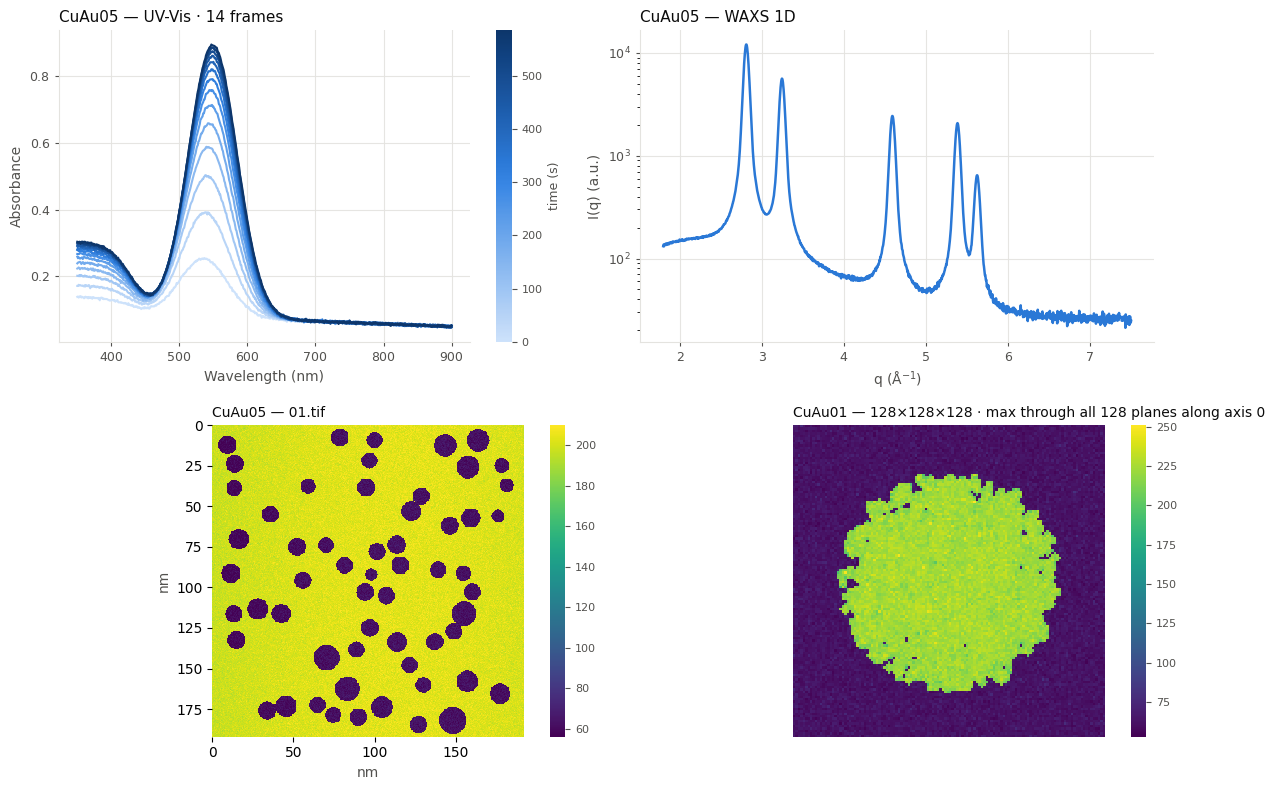

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
wb.plot("CuAu05", "uvvis", ax=axes[0, 0])
wb.plot("CuAu05", "waxs1d", ax=axes[0, 1])
wb.plot("CuAu05", "tem", ax=axes[1, 0])
wb.plot("CuAu01", "tomo", ax=axes[1, 1])
fig.tight_layout()

Note what happened without being asked:

* the UV-Vis frames were coloured **along one hue by time**, with a colour bar
  instead of a legend — a legend of fourteen timestamps is not readable, and
  the ordering is the information;
* the micrograph is drawn on **nanometre axes** because the TIFF carried a
  pixel calibration, so a distance read off it means something;
* the tomogram is a **slab projection**, not one plane — a single plane
  through a 150 nm aggregate shows one accident of where the plane fell.

## The layer below: frames

A measurement is rarely one number. It is fourteen spectra taken while the
reaction ran, each at its own time and temperature. `frames()` is that layer,
made addressable.

In [8]:
wb.frames("CuAu05", "uvvis").head(6)

,index,file,path,t_s,T_c,batch,scan,kind
0,0,uvvis_b05_t00000s_T30C.npy,/home/yuzhang/NanoOrganizerDemo/RawSpectra/uvv...,0.0,30.0,b05,-1,kinetic
1,1,uvvis_b05_t00045s_T35C.npy,/home/yuzhang/NanoOrganizerDemo/RawSpectra/uvv...,45.0,35.0,b05,-1,kinetic
2,2,uvvis_b05_t00090s_T40C.npy,/home/yuzhang/NanoOrganizerDemo/RawSpectra/uvv...,90.0,40.0,b05,-1,kinetic
3,3,uvvis_b05_t00135s_T45C.npy,/home/yuzhang/NanoOrganizerDemo/RawSpectra/uvv...,135.0,45.0,b05,-1,kinetic
4,4,uvvis_b05_t00180s_T50C.npy,/home/yuzhang/NanoOrganizerDemo/RawSpectra/uvv...,180.0,50.0,b05,-1,kinetic
5,5,uvvis_b05_t00225s_T55C.npy,/home/yuzhang/NanoOrganizerDemo/RawSpectra/uvv...,225.0,55.0,b05,-1,kinetic


`t` and `T` select the **nearest** recorded value rather than an exact one,
because an acquisition clock never lands on a round number.

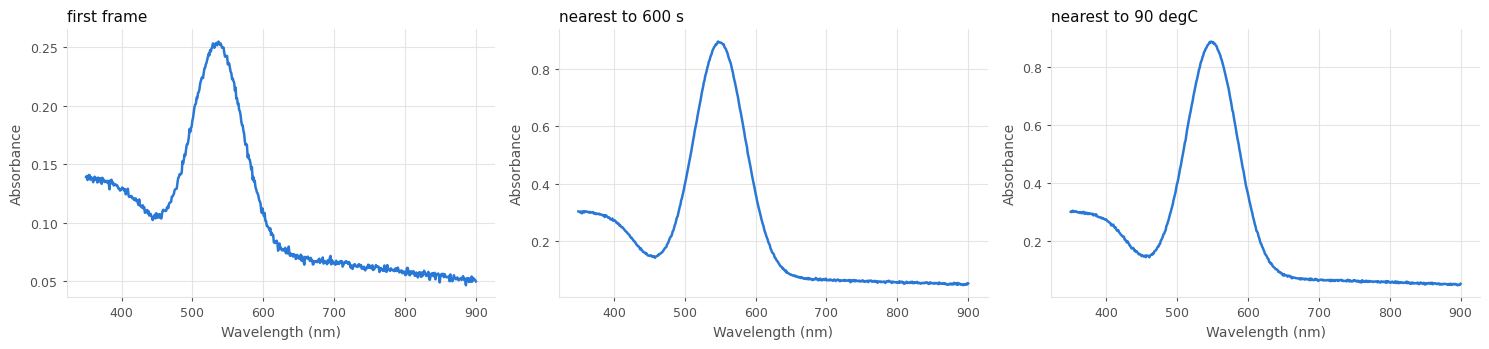

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
wb.plot("CuAu05", "uvvis", frame=0,  ax=axes[0], title="first frame")
wb.plot("CuAu05", "uvvis", t=600,    ax=axes[1], title="nearest to 600 s")
wb.plot("CuAu05", "uvvis", T=90,     ax=axes[2], title="nearest to 90 degC")
fig.tight_layout()

For the numbers rather than a picture, `data()` returns arrays. What comes
back follows the group, because that is what the data is — `(x, Y, info)` for
a curve, `(array, info)` for an image or a volume.

In [10]:
x, Y, info = wb.data("CuAu05", "uvvis")
print("curve :", x.shape, Y.shape, "|", info["source"])

image, meta = wb.data("CuAu05", "tem", frame=1)
print("image :", image.shape, "|", meta["file"], "|", meta["nm_per_pixel"], "nm/px")

volume, meta = wb.data("CuAu01", "tomo")
print("volume:", volume.shape, "|", meta["source"])

curve : (551,) (14, 551) | time series
image : (384, 384) | 02.tif | 0.5 nm/px
volume: (128, 128, 128) | single 3D file


## Across samples

`overlay` draws one curve per selected sample, collapsing each many-frame
measurement first. Samples whose files do not resolve are skipped and named,
rather than taking the figure down — a campaign always has one sample on a
mount that is not up today.

selected: ['CuAu01', 'CuAu02', 'CuAu03', 'CuAu04', 'CuAu05']


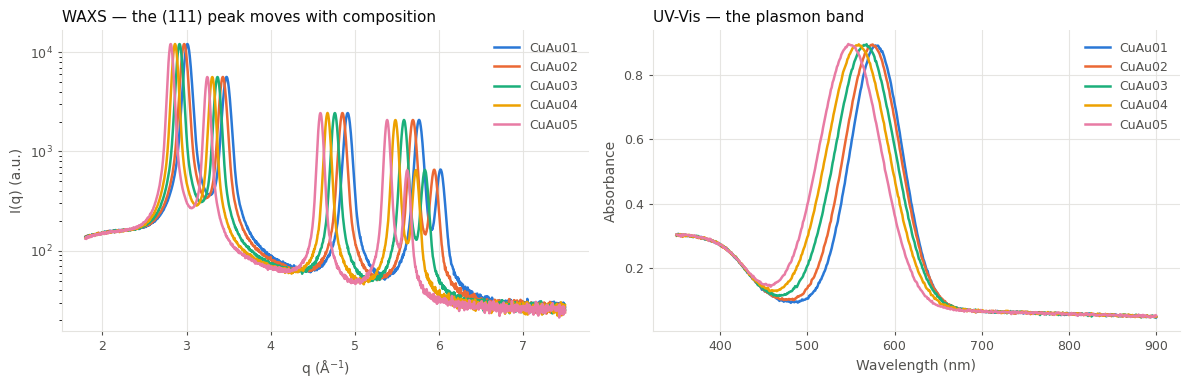

In [11]:
wb.filter("`synthesis.au_fraction` <= 0.55")
print("selected:", wb.basket)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
wb.overlay("waxs1d", ax=axes[0], title="WAXS — the (111) peak moves with composition")
wb.overlay("uvvis", reduce="last", ax=axes[1], title="UV-Vis — the plasmon band")
fig.tight_layout()
_ = wb.clear()

## Analyse, and close the loop

An analysis takes a measurement and writes derived values back onto the
sample, where they become columns in the same table as the authored
parameters. Linked data is ordinary data: nothing here knows it was linked.

In [12]:
wb.batch("peak_fit", modality="waxs1d", x_range=(2.5, 3.6), n_peaks=2,
         background="linear")
wb.batch("peak_fit", modality="uvvis", x_range=(450, 700), n_peaks=1)

wb.table()[["synthesis.au_fraction",
            "derived.waxs1d_peak1_center",
            "derived.uvvis_peak1_center"]].dropna()

peak_fit: 8/8 succeeded
peak_fit: 8/8 succeeded


,synthesis.au_fraction,derived.waxs1d_peak1_center,derived.uvvis_peak1_center
sample_id,,,
CuAu01,0.00,3.010332,579.030652
CuAu02,0.10,2.972310,574.032363
CuAu03,0.25,2.917015,566.096287
CuAu04,0.40,2.863716,557.642390
CuAu05,0.55,2.812317,548.674948
CuAu06,0.70,2.762724,539.165977
CuAu07,0.85,2.714846,529.141545
CuAu08,1.00,2.668595,518.624142


<Axes: title={'left': 'waxs1d_peak1_center vs au_fraction'}, xlabel='au_fraction', ylabel='waxs1d_peak1_center'>

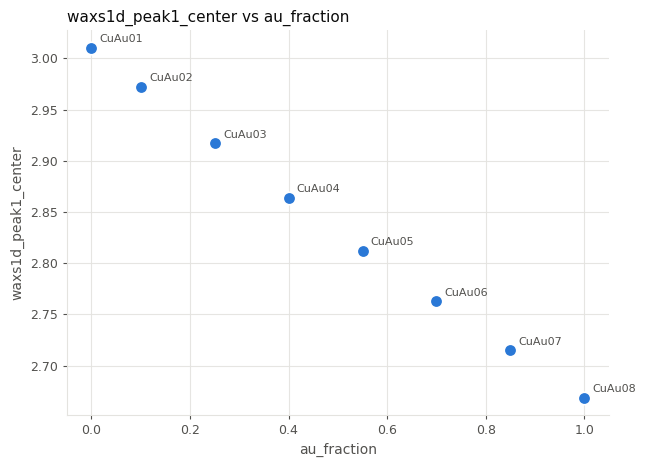

In [13]:
# Vegard's law: the diffraction peak measures composition. The point of
# keeping fifteen techniques in one table is that this plot can exist at all.
wb.plot_compare("synthesis.au_fraction", "derived.waxs1d_peak1_center")

## Save it

The store is two JSON files under `.nanoorganizer/`: the links and derived
values in `samples.json`, the aliases in `project.json`. The data is untouched
and stays where it was.

In [14]:
print(wb.save())

again = open_project(wb.project.root, ingest=False, attach=False)
print(again.summary())
print("derived survived:", again["CuAu05"].get_derived("waxs1d_peak1_center"))

/home/yuzhang/CuAuOrganizer/.nanoorganizer/samples.json
Cu-Au CO2RR library: 9 samples, 69 measurements (69 readable here, 0 not mounted).
Modalities: uvvis, saxs1d, waxs1d, raman, eds, dls, tem, sem, tomo, xpcs_g2
Root: /home/yuzhang/CuAuOrganizer
derived survived: 2.8123167609860165


## Three shortcuts for a whole campaign

The loop at the top is explicit on purpose, but a campaign rarely needs it.

**A nested dict** — `{sample: {modality: source}}`:

```python
wb.link_many({
    "CuAu01": {"waxs1d": f"{DATA}/Scattering/CuAu01/waxs_1d.dat",
               "tem": {"source": f"{DATA}/TEMData/CuAu01", "kV": 200}},
    "CuAu02": {"waxs1d": f"{DATA}/Scattering/CuAu02/waxs_1d.dat"},
}, stage="characterization")
```

**A spreadsheet** — columns `sample_id`, `modality`, `source`, optionally
`stage` / `role`; anything else becomes metadata. The table whoever ran the
instrument was keeping anyway is an ingest format, with no adapter to write:

```python
wb.link_table("session_log.csv")
```

**A live folder** — records the glob rather than today's listing, which is the
one to use while a run is still going:

```python
wb.link_folder("CuAu05", "tem", "/mnt/scope/session17", pattern="*.tif")
```

## Export it, edit it, bring it back

A spreadsheet is a better editor than a form when forty rows need the same
fix. `links_table()` is the export half of `link_table()`, and the pair is a
genuine round trip.

Each row records the **shortest form that re-imports to the same files**: a
pattern stays a pattern, a folder stays a folder, and explicit paths become a
`;`-joined list whenever listing the folder would not reproduce them exactly.
A re-import therefore cannot quietly link a different set of files.

It is a table of *links*, so `CuAu09` — the failed synthesis, which
has none — is not in it. That is why the rebuilt organizer below has
eight samples and not nine; parameters and empty samples live in the
store, which is what `save()` writes.

In [15]:
links = wb.links_table()
print(f"{len(links)} links")
links.head(4)

69 links


,sample_id,modality,source,stage,role,aux,instrument
0,CuAu01,uvvis,/home/yuzhang/NanoOrganizerDemo/RawSpectra/uvv...,synthesis,,"{""wavelength_file"": ""/home/yuzhang/NanoOrganiz...",DemoSpec HR4000
1,CuAu01,saxs1d,/home/yuzhang/NanoOrganizerDemo/Scattering/CuA...,characterization,,NaN,NaN
2,CuAu01,waxs1d,/home/yuzhang/NanoOrganizerDemo/Scattering/CuA...,characterization,,NaN,NaN
3,CuAu01,raman,/home/yuzhang/NanoOrganizerDemo/Spectroscopy/C...,characterization,,NaN,NaN


In [16]:
# Export, then rebuild a second organizer from the file alone.
export = wb.project.root / "links_export.csv"
links.to_csv(export, index=False)

rebuilt = new_organizer(Path.home() / "CuAuRebuilt")
rebuilt.link_table(export)

def signature(bench):
    return {m.measurement_id: (tuple(m.paths), m.pattern, m.aux)
            for m in bench.project.measurements()}

print("identical:", signature(rebuilt) == signature(wb))
print(rebuilt.summary())

identical: True
CuAuRebuilt: 8 samples, 69 measurements (69 readable here, 0 not mounted).
Modalities: uvvis, saxs1d, waxs1d, raman, eds, dls, tem, sem, tomo, xpcs_g2
Root: /home/yuzhang/CuAuRebuilt


## Revising it

Links and parameters are both editable in place. Nothing here touches a file —
only the record of where the files are and what the sample was.

In [17]:
# A sample with no data at all: the synthesis that failed is still a result,
# and leaving it out biases every comparison drawn afterwards.
wb.add_sample("CuAu09", status="error", error="precursor precipitated")

# A second measurement of one technique on one sample needs a role to tell
# them apart — an as-made and a post-reaction scan, say.
wb.link("CuAu05", "waxs1d", f"{DATA}/Scattering/CuAu05/waxs_1d.dat",
        role="post-reaction")
print("CuAu05 waxs:", [m.measurement_id for m in
                       wb["CuAu05"].get_measurements(modality="waxs1d")])

print("dropped:", wb.unlink("CuAu05", modality="waxs1d", role="post-reaction"))

CuAu05 waxs: ['CuAu05:waxs1d:characterization', 'CuAu05:waxs1d:characterization-post-reaction']
dropped: ['CuAu05:waxs1d:characterization-post-reaction']


## The same thing with buttons

Everything above has buttons, in the same order, on the **📁 Project** page:

| notebook | page |
|---|---|
| `new_organizer(root)` | **Open or create → Nothing yet** |
| `open_project(root)` | **Open or create → An existing project** |
| `link` / `link_folder` | **Link data from anywhere** — with a file-count preview before you commit |
| `link_table` | **Link a whole campaign from a table** |
| `set_params`, `add_sample`, `remove_sample` | **Samples and their conditions** — an editable grid |
| `links_table`, `save` | **Save and export** |

It is the same `Workbench` object either way, so an organizer this notebook
saved opens on that page with its links, parameters and derived values intact
— and one built with the buttons opens here.

```bash
streamlit run NanoOrganizer/web_app/Home.py       # or: viz
```

Then **🔎 Explore & Filter** for the table, **📈 Visualize** for the drawings
with controls on them, **🧪 Analyze** and **📊 Compare**.

---

Next: `05_multimodal_demo` is the full fifteen-technique tour of this same
campaign, and `docs/sample_model.md` is the model itself.